In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib, os

print('✅ All libraries imported!')
print(f'pandas version: {pd.__version__}')
print(f'numpy version:  {np.__version__}')

✅ All libraries imported!
pandas version: 3.0.3
numpy version:  2.4.6


In [ ]:
df = pd.read_csv('data/matches.csv')

print(f'✅ Dataset loaded!')
print(f'Shape: {df.shape[0]} matches × {df.shape[1]} columns')
print(f'Seasons: {df["season"].min()} → {df["season"].max()}')
print(f'\nColumn names:\n{list(df.columns)}')
df.head()

✅ Dataset loaded!
Shape: 1095 matches × 20 columns
Seasons: 2007/08 → 2024

Column names:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
print('📊 Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f'\n🏏 Unique teams: {df["team1"].nunique()}')
print(f'🏟️  Unique venues: {df["venue"].nunique()}')
print(f'📅 Seasons covered: {df["season"].nunique()}')

📊 Missing values per column:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

🏏 Unique teams: 19
🏟️  Unique venues: 58
📅 Seasons covered: 17


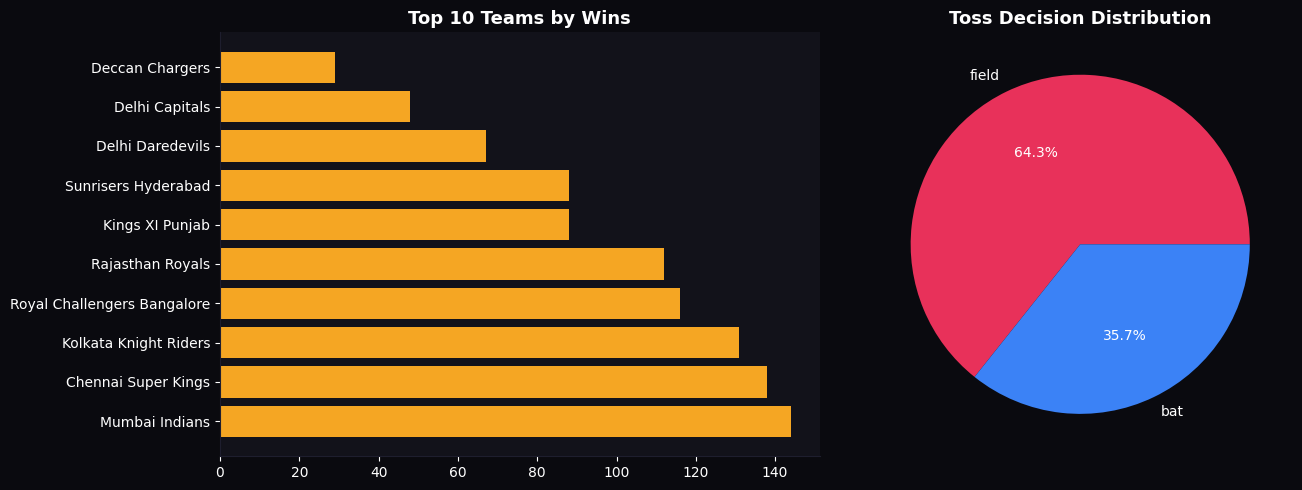

✅ Charts saved to data/eda_charts.png


In [ ]:
# Visualize most successful teams
# WHY: Seeing the data visually helps us understand patterns before modeling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0a0f')

# Plot 1: Top teams by wins
win_counts = df['winner'].value_counts().head(10)
axes[0].barh(win_counts.index, win_counts.values, color='#f5a623')
axes[0].set_title('Top 10 Teams by Wins', color='white', fontsize=13, fontweight='bold')
axes[0].set_facecolor('#12121a')
axes[0].tick_params(colors='white')
axes[0].spines['bottom'].set_color('#1e1e2e')
axes[0].spines['left'].set_color('#1e1e2e')
for spine in ['top','right']: axes[0].spines[spine].set_visible(False)

# Plot 2: Toss decision breakdown
toss_counts = df['toss_decision'].value_counts()
axes[1].pie(toss_counts.values, labels=toss_counts.index,
            autopct='%1.1f%%', colors=['#e8315a', '#3b82f6'],
            textprops={'color': 'white'})
axes[1].set_title('Toss Decision Distribution', color='white', fontsize=13, fontweight='bold')
axes[1].set_facecolor('#12121a')

plt.tight_layout()
plt.savefig('data/eda_charts.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print('✅ Charts saved to data/eda_charts.png')

In [ ]:
# Drop rows where winner is missing (abandoned matches)
# WHY: We can't train on data where we don't know the outcome
df = df.dropna(subset=['winner'])
print(f'✓ After dropping no-result matches: {len(df)} rows')

# Fix team names (rebranding over the years)
# WHY: Model sees 'Delhi Daredevils' and 'Delhi Capitals' as DIFFERENT teams otherwise
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df[col] = df[col].replace(team_name_map)
print('✓ Team names standardized')

# Select only useful features
# WHY: We only use data available BEFORE a match starts
features = ['team1', 'team2', 'venue', 'toss_winner', 'toss_decision']
df_model = df[features + ['winner']].copy()
print(f'✓ Final shape: {df_model.shape}')
df_model.head()

✓ After dropping no-result matches: 1090 rows
✓ Team names standardized
✓ Final shape: (1090, 6)


,team1,team2,venue,toss_winner,toss_decision,winner
0,Royal Challengers Bengaluru,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bengaluru,field,Kolkata Knight Riders
1,Punjab Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings
2,Delhi Capitals,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Capitals
3,Mumbai Indians,Royal Challengers Bengaluru,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bengaluru
4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,Kolkata Knight Riders


In [ ]:
label_encoders = {}  # WHY: Store encoders to decode predictions later

for col in df_model.columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print('✅ Encoding complete!')
print(f'\nTeam name → Number mapping (first 5):')
for i, name in enumerate(label_encoders['team1'].classes_[:5]):
    print(f'  {name:35} → {i}')

df_model.head()

✅ Encoding complete!

Team name → Number mapping (first 5):
  Chennai Super Kings                 → 0
  Deccan Chargers                     → 1
  Delhi Capitals                      → 2
  Gujarat Lions                       → 3
  Gujarat Titans                      → 4


,team1,team2,venue,toss_winner,toss_decision,winner
0,13,6,23,13,1,6
1,10,0,40,0,0,0
2,2,11,16,11,0,2
3,8,13,55,8,0,13
4,6,1,14,1,0,6


In [ ]:
X = df_model[features]      # WHY: X = inputs (what model sees)
y = df_model['winner']      # WHY: y = output (what model predicts)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'✂️  Split complete!')
print(f'  Training set : {X_train.shape[0]} matches (80%) → model LEARNS from these')
print(f'  Testing set  : {X_test.shape[0]} matches (20%) → model is EVALUATED on these')

✂️  Split complete!
  Training set : 872 matches (80%) → model LEARNS from these
  Testing set  : 218 matches (20%) → model is EVALUATED on these


In [ ]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)   # WHY: .fit() = the learning step
dt_acc = accuracy_score(y_test, dt.predict(X_test)) * 100
print(f'🌳 Decision Tree  → Accuracy: {dt_acc:.2f}%')

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test)) * 100
print(f'🌲 Random Forest  → Accuracy: {rf_acc:.2f}%')

best = rf if rf_acc >= dt_acc else dt
best_name = 'Random Forest' if rf_acc >= dt_acc else 'Decision Tree'
print(f'\n🏆 Best Model: {best_name}')

🌳 Decision Tree  → Accuracy: 56.42%
🌲 Random Forest  → Accuracy: 53.67%

🏆 Best Model: Decision Tree


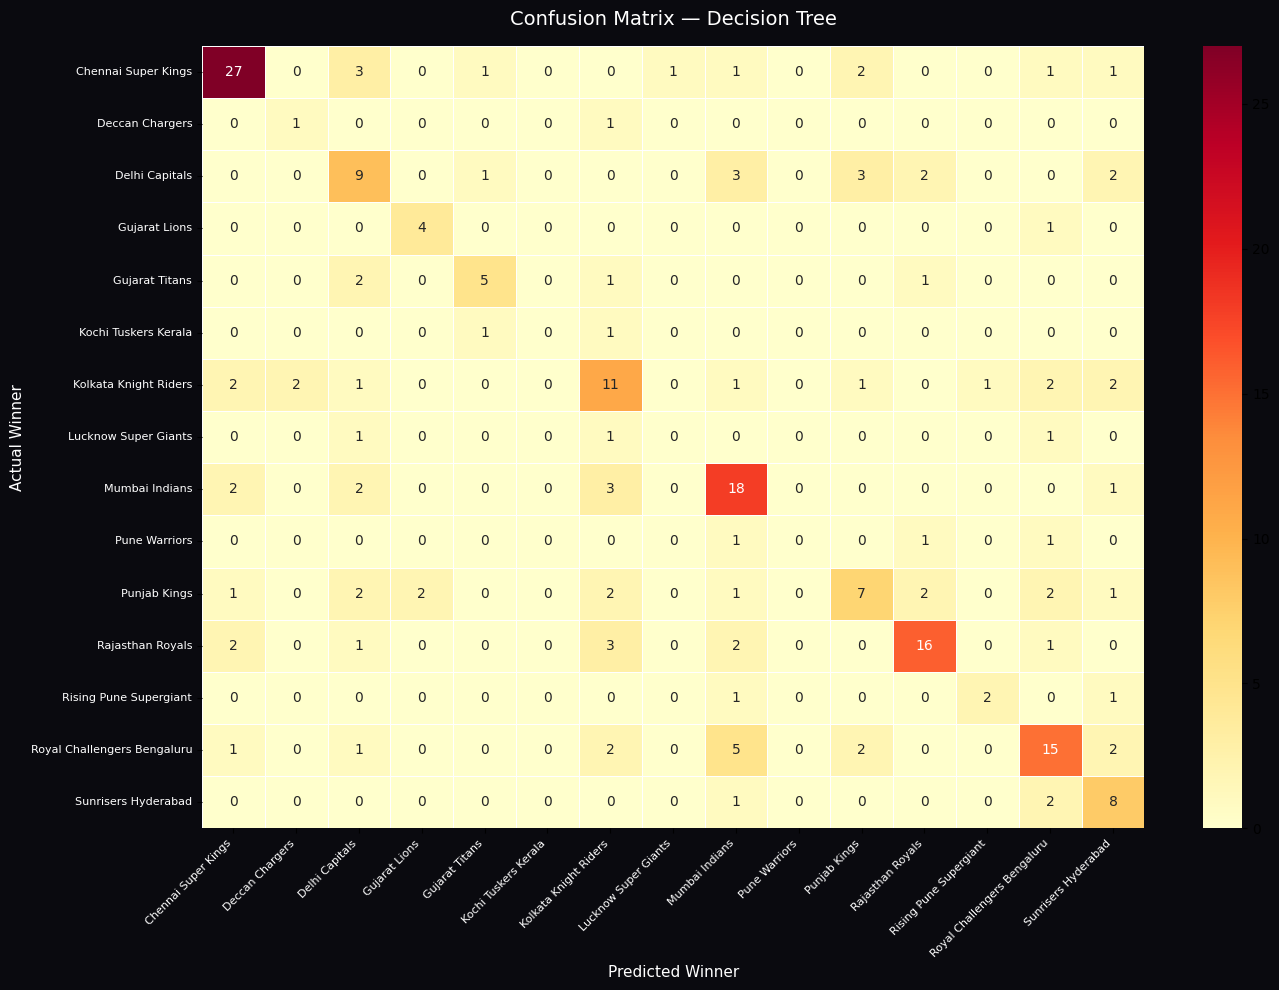

In [ ]:
best_pred = best.predict(X_test)
team_names = label_encoders['winner'].classes_

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(14, 10), facecolor='#0a0a0f')
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=team_names, yticklabels=team_names,
            linewidths=0.5)
ax.set_facecolor('#12121a')
plt.title(f'Confusion Matrix — {best_name}', color='white', fontsize=14, pad=15)
plt.xlabel('Predicted Winner', color='white', fontsize=11)
plt.ylabel('Actual Winner', color='white', fontsize=11)
plt.xticks(rotation=45, ha='right', color='white', fontsize=8)
plt.yticks(rotation=0, color='white', fontsize=8)
plt.tight_layout()
plt.savefig('data/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

In [ ]:
# Full classification report
# WHY: Shows precision/recall/F1 per team — much more detailed than just accuracy
print(f'📋 Classification Report — {best_name}:')
print(classification_report(y_test, best_pred, target_names=team_names, zero_division=0))

📋 Classification Report — Decision Tree:
                             precision    recall  f1-score   support

        Chennai Super Kings       0.77      0.73      0.75        37
            Deccan Chargers       0.33      0.50      0.40         2
             Delhi Capitals       0.41      0.45      0.43        20
              Gujarat Lions       0.67      0.80      0.73         5
             Gujarat Titans       0.62      0.56      0.59         9
       Kochi Tuskers Kerala       0.00      0.00      0.00         2
      Kolkata Knight Riders       0.44      0.48      0.46        23
       Lucknow Super Giants       0.00      0.00      0.00         3
             Mumbai Indians       0.53      0.69      0.60        26
              Pune Warriors       0.00      0.00      0.00         3
               Punjab Kings       0.47      0.35      0.40        20
           Rajasthan Royals       0.73      0.64      0.68        25
     Rising Pune Supergiant       0.67      0.50      0.57   

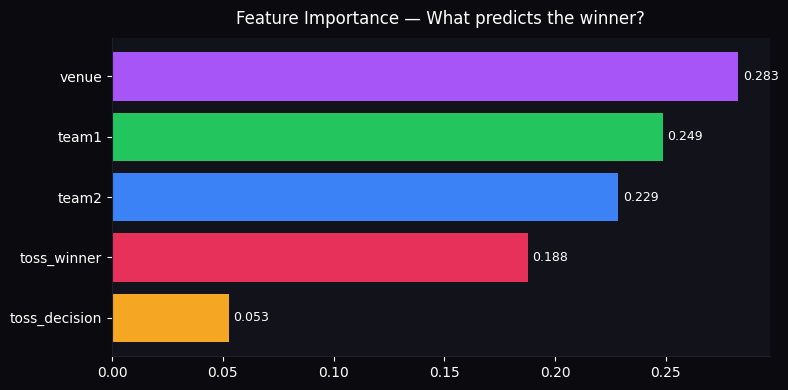

In [ ]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4), facecolor='#0a0a0f')
ax = plt.gca()
ax.set_facecolor('#12121a')
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=['#f5a623','#e8315a','#3b82f6','#22c55e','#a855f7'])
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=9)
ax.set_title('Feature Importance — What predicts the winner?', color='white', fontsize=12, pad=10)
ax.tick_params(colors='white')
for spine in ['top','right']: ax.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax.spines[spine].set_color('#1e1e2e')
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

In [ ]:
os.makedirs('models', exist_ok=True)
joblib.dump(rf, 'models/random_forest.pkl')
joblib.dump(dt, 'models/decision_tree.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')
print('💾 Models saved to /models/ folder!')

💾 Models saved to /models/ folder!


In [ ]:
def predict_winner(team1, team2, venue, toss_winner, toss_decision):
    """Predict IPL match winner given match details."""
    encoders = joblib.load('models/label_encoders.pkl')
    model = joblib.load('models/random_forest.pkl')
    
    try:
        input_data = pd.DataFrame([[
            encoders['team1'].transform([team1])[0],
            encoders['team2'].transform([team2])[0],
            encoders['venue'].transform([venue])[0],
            encoders['toss_winner'].transform([toss_winner])[0],
            encoders['toss_decision'].transform([toss_decision])[0]
        ]], columns=features)
        
        pred_encoded = model.predict(input_data)[0]
        winner = encoders['winner'].inverse_transform([pred_encoded])[0]
        proba = model.predict_proba(input_data)[0]
        confidence = round(max(proba) * 100, 1)
        
        return winner, confidence
    except ValueError as e:
        return f'Error: {e}', 0

# --- Test it! ---
test_matches = [
    ("Mumbai Indians", "Punjab Kings", "Wankhede Stadium", "Mumbai Indians", "bat"),
    ("Chennai Super Kings", "Kolkata Knight Riders", "MA Chidambaram Stadium", "Chennai Super Kings", "field"),
]

print('🎯 PREDICTIONS:')
print('-' * 55)
for t1, t2, v, tw, td in test_matches:
    w, c = predict_winner(t1, t2, v, tw, td)
    print(f'  {t1} vs {t2}')
    print(f'  Toss: {tw} chose to {td}')
    print(f'  🏆 Predicted Winner: {w} ({c}% confidence)')
    print()

🎯 PREDICTIONS:
-------------------------------------------------------
  Mumbai Indians vs Punjab Kings
  Toss: Mumbai Indians chose to bat
  🏆 Predicted Winner: Punjab Kings (78.4% confidence)

  Chennai Super Kings vs Kolkata Knight Riders
  Toss: Chennai Super Kings chose to field
  🏆 Predicted Winner: Chennai Super Kings (71.9% confidence)

